In [90]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Reading, Cleaning, and Understanding Data

In this section, we load the sales data from a CSV file, remove any missing values, and explore the dataset structure to understand its contents.

In [91]:
data = pd.read_csv('Sales_October_2019.csv')
data = data.dropna()

data['Order Date'] = pd.to_datetime(data['Order Date'], format='mixed')
data['Quantity Ordered'] = pd.to_numeric(data['Quantity Ordered'], errors='coerce')
data['Price Each'] = pd.to_numeric(data['Price Each'], errors='coerce')
data['Hour'] = data['Order Date'].dt.hour
data['City'] = data['Purchase Address'].apply(lambda x: x.split(',')[1].strip()) + data['Purchase Address'].apply(lambda x: ' (' + x.split(',')[2].split(' ')[1] + ')')
print(data.info())
print(data.head())

<class 'pandas.DataFrame'>
Index: 20284 entries, 0 to 20345
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order ID          20284 non-null  float64       
 1   Product           20284 non-null  str           
 2   Quantity Ordered  20284 non-null  float64       
 3   Price Each        20284 non-null  float64       
 4   Order Date        20284 non-null  datetime64[us]
 5   Purchase Address  20284 non-null  str           
 6   Hour              20284 non-null  int32         
 7   City              20284 non-null  str           
dtypes: datetime64[us](1), float64(3), int32(1), str(3)
memory usage: 1.3 MB
None
   Order ID                 Product  Quantity Ordered  Price Each  \
0  259358.0  34in Ultrawide Monitor               1.0      379.99   
1  259359.0  27in 4K Gaming Monitor               1.0      389.99   
2  259360.0  AAA Batteries (4-pack)               2.0        2.99   
3  259361.

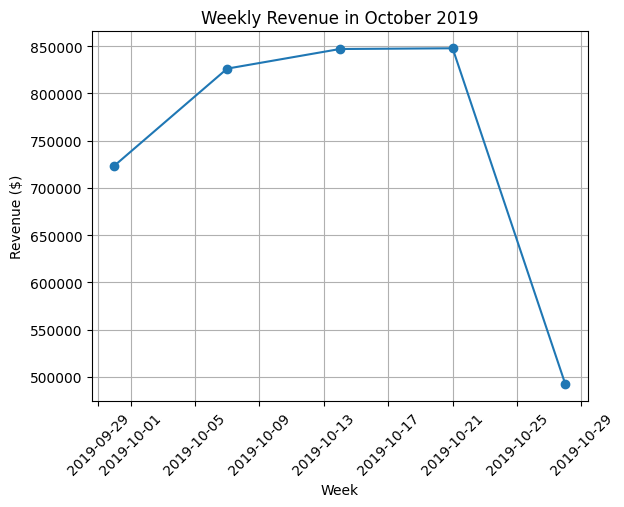

In [92]:
data['Revenue'] = data['Quantity Ordered'] * data['Price Each']
    
data['Week'] = data['Order Date'].dt.to_period('W')  # W for week
weekly_revenue = data.groupby('Week')['Revenue'].sum()

plt.plot(weekly_revenue.index.to_timestamp(), weekly_revenue.values, marker='o')
plt.xticks(rotation=45)
plt.title('Weekly Revenue in October 2019')
plt.xlabel('Week')
plt.ylabel('Revenue ($)')
plt.grid()
plt.show()

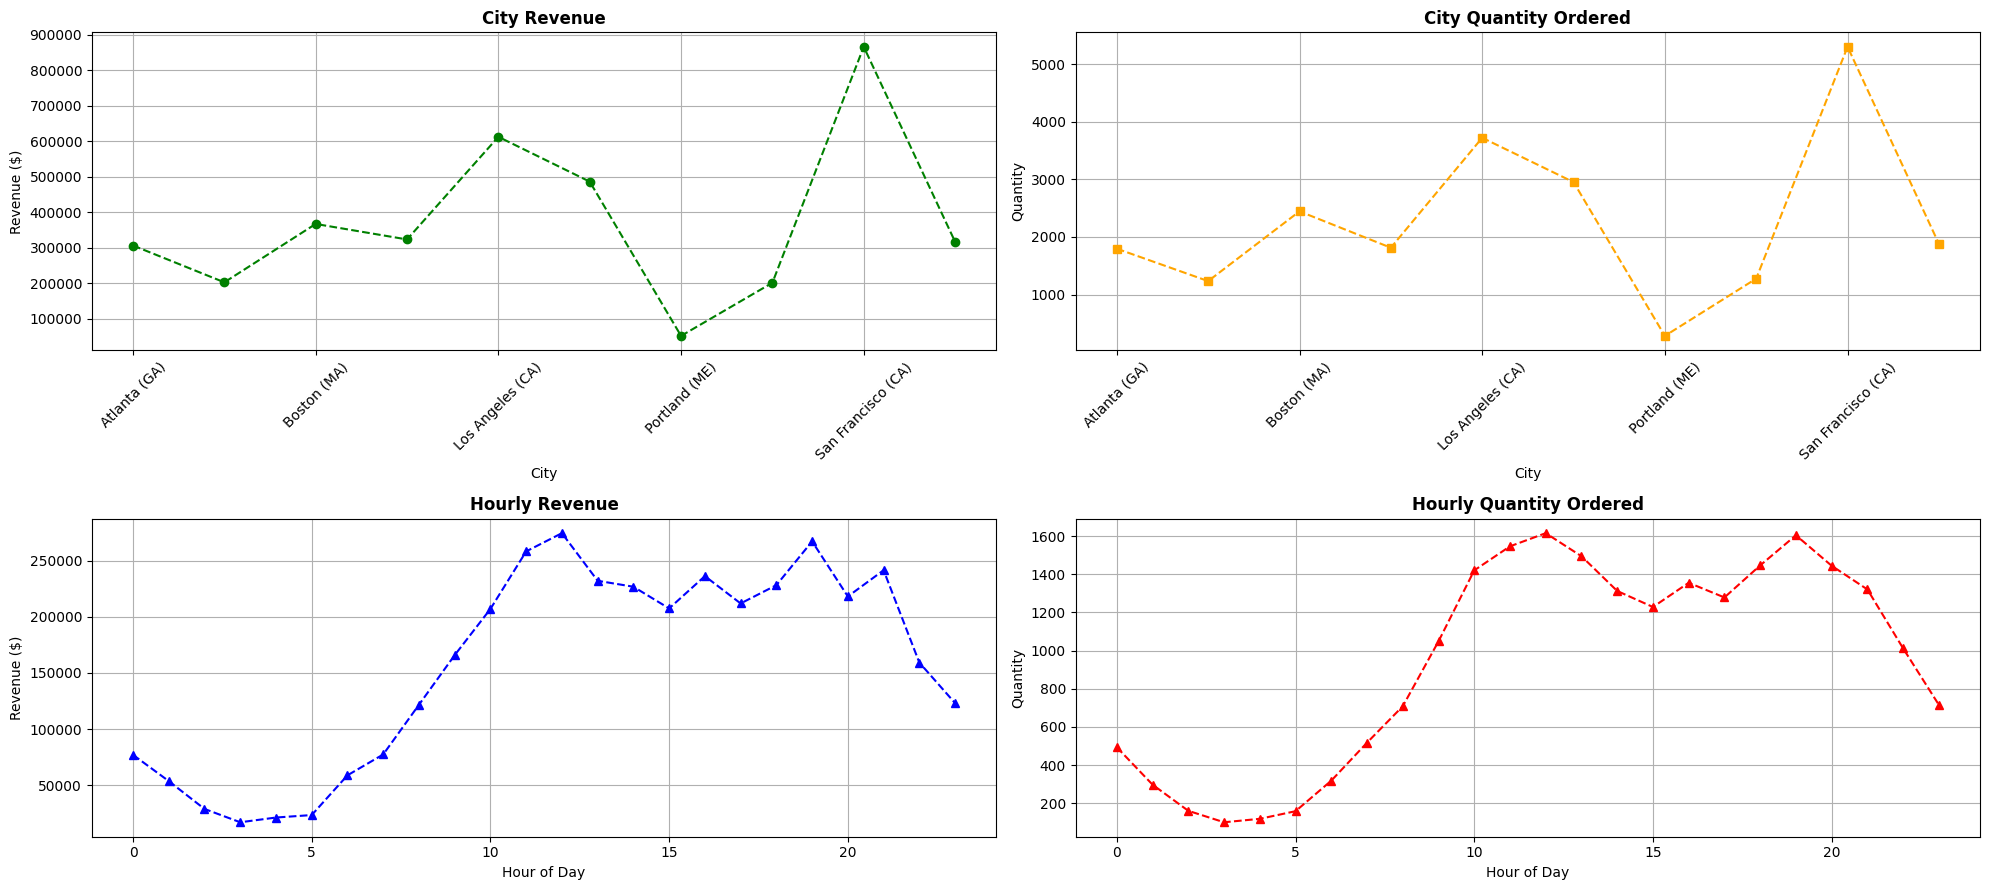

In [93]:
fig, axes = plt.subplots(2, 2, figsize=(20, 9))


# Subplot 1: City Revenue (left)
city_groupby_revenue = data.groupby('City')['Revenue'].sum()
city_groupby_revenue.plot(ax=axes[0,0], marker='o', linestyle='--', color='green')
axes[0,0].set_title("City Revenue", fontsize=12, fontweight='bold')
axes[0,0].set_xlabel("City")
axes[0,0].set_ylabel("Revenue ($)")
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid()

# Subplot 2: City Quantity (right)
city_groupby_quantity = data.groupby('City')['Quantity Ordered'].sum()
city_groupby_quantity.plot(ax=axes[0,1], marker='s', linestyle='--', color='orange')
axes[0,1].set_title("City Quantity Ordered", fontsize=12, fontweight='bold')
axes[0,1].set_xlabel("City")
axes[0,1].set_ylabel("Quantity")
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid()

# Subplot 3: Hourly Revenue (bottom left)
hourly_revenue = data.groupby('Hour')['Revenue'].sum()
hourly_revenue.plot(ax=axes[1,0], marker='^', linestyle='--', color='blue')
axes[1,0].set_title("Hourly Revenue", fontsize=12, fontweight='bold')
axes[1,0].set_xlabel("Hour of Day")
axes[1,0].set_ylabel("Revenue ($)") 
axes[1,0].grid()

hourly_quantity = data.groupby('Hour')['Quantity Ordered'].sum()
hourly_quantity.plot(ax=axes[1,1], marker='^', linestyle='--', color='red')
axes[1,1].set_title("Hourly Quantity Ordered", fontsize=12, fontweight='bold')
axes[1,1].set_xlabel("Hour of Day")
axes[1,1].set_ylabel("Quantity") 
axes[1,1].grid()


# Adjust layout to avoid overlapping
plt.tight_layout()
plt.show()

In [104]:
duplicate = data[data.duplicated(subset=['Order ID'], keep=False)]
duplicate['Grouped'] = duplicate.groupby('Order ID')['Product'].transform(lambda x: ','.join(x))
duplicate = duplicate[['Order ID', 'Grouped']].drop_duplicates()
duplicate['Count'] = duplicate['Grouped'].apply(lambda x: len(x.split(',')))
from itertools import combinations
from collections import Counter
count = Counter()
for products in duplicate['Grouped']:
    product_list = products.split(',')
    count.update(Counter(combinations(product_list, 2)))

for combo, freq in count.most_common(10):
    print(f"Products: {combo}, Frequency: {freq}")  

Products: ('Google Phone', 'USB-C Charging Cable'), Frequency: 105
Products: ('iPhone', 'Lightning Charging Cable'), Frequency: 92
Products: ('iPhone', 'Wired Headphones'), Frequency: 57
Products: ('Google Phone', 'Wired Headphones'), Frequency: 54
Products: ('iPhone', 'Apple Airpods Headphones'), Frequency: 41
Products: ('Vareebadd Phone', 'USB-C Charging Cable'), Frequency: 41
Products: ('Google Phone', 'Bose SoundSport Headphones'), Frequency: 33
Products: ('USB-C Charging Cable', 'Wired Headphones'), Frequency: 17
Products: ('Vareebadd Phone', 'Wired Headphones'), Frequency: 16
Products: ('Lightning Charging Cable', 'Wired Headphones'), Frequency: 14
